# Extreme Returns and Fat Tails in Stock Returns

## 1. Motivation

 이전 분석에서는 주식수익률이 정규분포를 따르는지 확인하였다. 그 결과, 실제 수익률 자료는 정규분포 가정과 잘 맞지 않는다는 점을 확인할 수 있었다.

다만 정규성 가정이 성립하지 않는다는 사실만으로는 분석이 다소 추상적으로 남는다. 금융 데이터에서 더 중요한 문제는 정규분포에서 벗어난다는 사실 자체가 아니라, 그 차이가 주로 어디에서 발생하는가이다. 특히 자산 수익률의 경우, 평균 근처의 작은 변동보다 분포의 양쪽 꼬리에서 나타나는 극단적인 수익률이 더 큰 의미를 갖는다.

정규분포를 따른다면 매우 드물게 발생해야 할 큰 폭의 상승이나 하락이 실제 시장에서는 생각보다 자주 관찰된다. 이러한 현상은 일반적으로 **fat tail**이라고 부르며, 금융시장에서는 단순한 통계적 특징을 넘어 위험관리와 자산가격결정에 직접적인 영향을 미친다.

본 분석에서는 이러한 점을 고려하여, 정규성 검정을 다시 반복하기보다는 실제 수익률 자료에서 극단적인 수익률이 얼마나 자주 발생하는지를 살펴보고자 한다. 구체적으로는 일별 로그수익률을 계산한 뒤, 이를 표준화하여 다음과 같은 사건의 빈도를 확인한다.

$$
|r_t| > 2\sigma, \quad |r_t| > 3\sigma, \quad |r_t| > 4\sigma
$$

여기서 $r_t$는 일별 로그수익률이고, $\sigma$는 수익률의 표준편차이다.  
만약 표준화된 수익률이 표준정규분포를 따른다면,

$$
Z_t = \frac{r_t - \mu}{\sigma} \sim N(0,1)
$$

절댓값 기준으로 $3\sigma$를 초과하는 사건은 약 0.27% 정도만 발생해야 한다.

$$
P(|Z_t| > 3) \approx 0.0027
$$

하지만 실제 주식수익률에서는 이러한 극단값이 이론적 확률보다 훨씬 자주 나타날 수 있다.  
따라서 본 분석의 핵심은 단순히 “정규분포가 아니다”라는 결론을 반복하는 것이 아니라, 실제 시장 자료에서 꼬리 부분의 확률이 정규분포의 예측과 얼마나 다른지를 직접 확인하는 데 있다.

이를 통해 정규분포 기반의 위험 측정이 극단적인 시장 움직임을 얼마나 과소평가할 수 있는지, 그리고 왜 금융 데이터 분석에서 fat tail을 별도로 고려해야 하는지를 살펴보고자 한다.

## 2. Data

이번 분석에서도 Yahoo Finance에서 제공하는 일별 주가 데이터를 사용한다.  
데이터 수집에는 Python의 `yfinance` 라이브러리를 사용하였다.



In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

분석 대상은 미국 시장에서 거래가 활발하고 시장 대표성이 높은 대형주들로 구성하였다.

In [27]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "NVDA", "TSLA", "JPM", "XOM", "JNJ",
    "PG", "UNH", "HD", "V", "MA",
    "KO", "PEP", "MRK", "ABBV", "BAC"
]

분석 기간은 2015년부터 2025년까지로 설정하였다.

In [28]:
start_date = "2015-01-01"
end_date = "2025-12-31"

raw_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)





다운로드한 자료에는 시가, 고가, 저가, 종가, 수정종가, 거래량 등이 포함되어 있다.  
수익률 분석에서는 주식분할과 배당 효과가 반영된 수정종가를 사용하는 것이 일반적이므로, 본 분석에서도 `Adj Close`를 기준 가격으로 사용한다.



In [29]:
prices = raw_data["Adj Close"]
prices.head()
prices.info()
prices.describe()
#결측치 확인
prices.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2765 non-null   float64
 1   ABBV    2765 non-null   float64
 2   AMZN    2765 non-null   float64
 3   BAC     2765 non-null   float64
 4   GOOGL   2765 non-null   float64
 5   HD      2765 non-null   float64
 6   JNJ     2765 non-null   float64
 7   JPM     2765 non-null   float64
 8   KO      2765 non-null   float64
 9   MA      2765 non-null   float64
 10  META    2765 non-null   float64
 11  MRK     2765 non-null   float64
 12  MSFT    2765 non-null   float64
 13  NVDA    2765 non-null   float64
 14  PEP     2765 non-null   float64
 15  PG      2765 non-null   float64
 16  TSLA    2765 non-null   float64
 17  UNH     2765 non-null   float64
 18  V       2765 non-null   float64
 19  XOM     2765 non-null   float64
dtypes: float64(20)
memory usage: 453.6 KB


Ticker
AAPL     0
ABBV     0
AMZN     0
BAC      0
GOOGL    0
HD       0
JNJ      0
JPM      0
KO       0
MA       0
META     0
MRK      0
MSFT     0
NVDA     0
PEP      0
PG       0
TSLA     0
UNH      0
V        0
XOM      0
dtype: int64

여기까지가 실제 분석에 사용할 가격 자료를 불러오는 단계이다.  
다음 단계에서는 이 가격 자료를 일별 로그수익률로 변환하고, 극단수익률 분석을 위해 수익률을 표준화한다.

일별 로그수익률은 다음과 같이 정의된다.

$$
r_t = \ln \left( \frac{P_t}{P_{t-1}} \right)
$$

여기서 $P_t$는 시점 $t$의 수정종가이다.

## 3. Data Preprocessing

이제 수정종가 자료를 분석에 사용할 수 있는 형태로 변환한다.  
먼저 결측치를 제거한 뒤, 가격 자료를 일별 로그수익률로 변환한다. 로그수익률은 연속복리수익률에 해당하며, 시계열 수익률을 다룰 때 계산과 해석이 비교적 편리하다는 장점이 있다.

또한 본 분석의 목적은 종목별 극단수익률을 비교하는 것이므로, 단순한 수익률 크기만 비교하는 것은 적절하지 않을 수 있다. 변동성이 큰 종목은 동일한 수익률 변화도 상대적으로 덜 극단적인 사건일 수 있고, 변동성이 작은 종목은 작은 변화도 더 큰 충격으로 해석될 수 있기 때문이다.

따라서 각 종목의 로그수익률을 평균과 표준편차를 기준으로 표준화한다.

$$
Z_t = \frac{r_t - \mu}{\sigma}
$$

여기서 $r_t$는 일별 로그수익률, $\mu$는 해당 종목의 평균 로그수익률, $\sigma$는 해당 종목의 로그수익률 표준편차이다.

표준화된 수익률을 이용하면 서로 다른 변동성을 가진 종목들도 같은 기준에서 비교할 수 있다.

In [30]:
# 결측치 확인
missing_values = prices.isna().sum()

# 결측치가 포함된 행 제거
prices_clean = prices.dropna()

# 일별 로그수익률 계산
log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

# 로그수익률 표준화
rets_std = (log_returns - log_returns.mean()) / log_returns.std()

# 전처리 결과 확인
print("종목별 결측치 개수:")
print(missing_values)

print("\n결측치 제거 후 가격 자료의 크기:")
print(prices_clean.shape)

print("\n일별 로그수익률:")
display(log_returns.head())

print("\n표준화된 수익률:")
display(rets_std.head())

print("\n표준화된 수익률의 기초통계량:")
display(rets_std.describe())

종목별 결측치 개수:
Ticker
AAPL     0
ABBV     0
AMZN     0
BAC      0
GOOGL    0
HD       0
JNJ      0
JPM      0
KO       0
MA       0
META     0
MRK      0
MSFT     0
NVDA     0
PEP      0
PG       0
TSLA     0
UNH      0
V        0
XOM      0
dtype: int64

결측치 제거 후 가격 자료의 크기:
(2765, 20)

일별 로그수익률:


Ticker,AAPL,ABBV,AMZN,BAC,GOOGL,HD,JNJ,JPM,KO,MA,META,MRK,MSFT,NVDA,PEP,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028576,-0.018999,-0.020731,-0.029481,-0.019238,-0.021203,-0.007009,-0.031537,0.000000,-0.028531,-0.016191,0.014753,-0.009238,-0.017034,-0.007547,-0.004766,-0.042950,-0.016609,-0.022321,-0.027744
2015-01-06,0.000094,-0.004962,-0.023098,-0.030376,-0.024989,-0.003067,-0.004926,-0.026271,0.007565,-0.002164,-0.013565,0.038531,-0.014786,-0.030787,-0.007603,-0.004565,0.005648,-0.002020,-0.006464,-0.005330
2015-01-07,0.013925,0.039621,0.010544,0.004734,-0.002945,0.033701,0.021836,0.001525,0.012405,0.015436,0.000000,0.021160,0.012625,-0.002609,0.028822,0.005231,-0.001563,0.010159,0.013309,0.010082
2015-01-08,0.037703,0.010405,0.006813,0.020451,0.003478,0.021883,0.007832,0.022100,0.012023,0.015434,0.026309,0.019927,0.028994,0.036927,0.018011,0.011371,-0.001566,0.046630,0.013323,0.016508
2015-01-09,0.001072,-0.027736,-0.011818,-0.018092,-0.012286,-0.017297,-0.013722,-0.017540,-0.011093,-0.012826,-0.005644,-0.004625,-0.008441,0.004020,-0.006794,-0.009374,-0.018981,-0.009404,-0.014934,-0.001411



표준화된 수익률:


Ticker,AAPL,ABBV,AMZN,BAC,GOOGL,HD,JNJ,JPM,KO,MA,META,MRK,MSFT,NVDA,PEP,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-1.622047,-1.162702,-1.050550,-1.548030,-1.110335,-1.411440,-0.641522,-1.887209,-0.027557,-1.763341,-0.711658,1.013113,-0.599409,-0.629858,-0.651079,-0.432721,-1.218119,-0.932907,-1.502930,-1.620575
2015-01-06,-0.043065,-0.330555,-1.165095,-1.594293,-1.427475,-0.233613,-0.460105,-1.578935,0.645950,-0.173562,-0.601493,2.687336,-0.927199,-1.081225,-0.655810,-0.415455,0.121413,-0.137192,-0.464744,-0.323809
2015-01-07,0.718627,2.312450,0.462680,0.219105,-0.211894,2.154123,1.870369,0.048286,1.076875,0.887593,-0.032560,1.464261,0.692477,-0.156416,2.377224,0.424659,-0.077356,0.527059,0.829917,0.567869
2015-01-08,2.028187,0.580438,0.282145,1.030855,0.142312,1.386677,0.650862,1.252807,1.042840,0.887519,1.070876,1.377383,1.659677,1.141154,1.477059,0.951158,-0.077422,2.516298,0.830806,0.939668
2015-01-09,0.010778,-1.680693,-0.619316,-0.959822,-0.727001,-1.157738,-1.226159,-1.067785,-1.015160,-0.816399,-0.269283,-0.351264,-0.552290,0.061148,-0.588399,-0.827868,-0.557437,-0.539957,-1.019270,-0.097042



표준화된 수익률의 기초통계량:


Ticker,AAPL,ABBV,AMZN,BAC,GOOGL,HD,JNJ,JPM,KO,MA,META,MRK,MSFT,NVDA,PEP,PG,TSLA,UNH,V,XOM
count,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2764.000000,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03,2.764000e+03
mean,1.285352e-17,-1.478155e-17,-5.141409e-18,2.570705e-18,1.092549e-17,-6.426761e-18,3.213381e-19,-1.285352e-18,2.249366e-17,0.000000,1.510289e-17,-1.928028e-18,-8.997466e-18,-5.141409e-18,-5.141409e-18,-6.426761e-18,-1.735226e-17,1.670958e-17,2.570705e-18,1.285352e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-7.632428e+00,-1.055101e+01,-7.372908e+00,-8.661305e+00,-6.869940e+00,-1.435871e+01,-9.243016e+00,-9.530915e+00,-9.084363e+00,-8.249800,-1.288317e+01,-7.336924e+00,-9.475492e+00,-6.887833e+00,-1.012790e+01,-7.864673e+00,-6.553459e+00,-1.384499e+01,-9.572647e+00,-7.559417e+00
25%,-4.511418e-01,-4.422863e-01,-4.750239e-01,-4.800580e-01,-4.748777e-01,-4.676753e-01,-4.567432e-01,-4.530652e-01,-4.479758e-01,-0.443963,-4.307353e-01,-4.874082e-01,-4.520174e-01,-4.806397e-01,-4.554750e-01,-4.643553e-01,-4.940002e-01,-4.190929e-01,-4.517795e-01,-4.908150e-01
50%,4.111760e-03,3.087887e-02,4.854712e-03,9.572124e-04,2.182439e-02,1.284333e-02,9.232864e-03,-4.670095e-04,1.529830e-02,0.041880,8.885191e-03,-8.462128e-04,2.955279e-03,1.620522e-02,9.200120e-03,2.589975e-02,3.917441e-04,1.632840e-02,4.667590e-02,1.181890e-04
75%,5.005693e-01,4.862416e-01,5.028173e-01,5.041624e-01,4.980494e-01,5.085588e-01,4.897191e-01,4.799473e-01,4.950210e-01,0.475472,4.740994e-01,5.166584e-01,5.011164e-01,5.058097e-01,4.876767e-01,5.136010e-01,5.003996e-01,4.392266e-01,4.957859e-01,5.045174e-01
max,7.806287e+00,7.610234e+00,6.347957e+00,8.433938e+00,8.257688e+00,8.332698e+00,6.669061e+00,9.654703e+00,5.561961e+00,9.222455,8.746207e+00,6.945784e+00,7.801094e+00,8.491106e+00,1.010739e+01,9.701758e+00,5.602143e+00,6.541963e+00,8.447025e+00,6.895123e+00


위 과정을 통해 원래의 가격 자료는 일별 로그수익률 자료로 변환되었고, 다시 종목별 평균과 표준편차를 기준으로 표준화되었다.

이제 `rets_std`는 각 종목의 표준화된 수익률을 담고 있다.  
따라서 다음 단계에서는 이 자료를 이용하여 $|Z_t| > 2$, $|Z_t| > 3$, $|Z_t| > 4$와 같은 극단수익률이 실제로 얼마나 자주 발생하는지 계산할 수 있다.

이 빈도를 정규분포가 예측하는 이론적 확률과 비교하면, 실제 주식수익률의 꼬리가 정규분포보다 얼마나 두꺼운지 확인할 수 있다.

## 4. Empirical Tail Probabilities

이제 표준화된 수익률 `rets_std`를 이용하여 실제 극단수익률의 발생 빈도를 계산한다.

정규분포를 기준으로 하면, 표준화된 수익률 $Z_t$가 특정 표준편차 범위를 초과할 확률은 이론적으로 정해져 있다. 예를 들어 $|Z_t| > 3$인 사건은 정규분포하에서 약 0.27% 정도만 발생해야 한다.

하지만 실제 주식수익률에서는 이러한 극단값이 훨씬 자주 나타날 수 있다.  
따라서 본 절에서는 다음과 같은 사건의 실제 발생 빈도를 계산하고, 이를 정규분포의 이론적 확률과 비교한다.

$$
|Z_t| > 2, \quad |Z_t| > 3, \quad |Z_t| > 4, \quad |Z_t| > 5
$$

이 비교를 통해 실제 수익률 분포의 꼬리가 정규분포보다 얼마나 두꺼운지 확인할 수 있다.

In [31]:
from scipy.stats import norm

# 극단수익률 기준 설정
thresholds = [2, 3, 4, 5]

# 실제 자료에서 관찰된 극단수익률 발생 빈도
empirical_probs = [
    (rets_std.abs() > threshold).mean().mean()
    for threshold in thresholds
]

# 정규분포에서의 이론적 꼬리확률
normal_probs = [
    2 * (1 - norm.cdf(threshold))
    for threshold in thresholds
]

# 실제 빈도와 정규분포 이론 빈도 비교
tail_prob_table = pd.DataFrame({
    "Threshold": [f"|Z| > {threshold}" for threshold in thresholds],
    "Empirical Probability": empirical_probs,
    "Normal Probability": normal_probs
})

# 실제 빈도가 정규분포 이론 빈도의 몇 배인지 계산
tail_prob_table["Ratio"] = (
    tail_prob_table["Empirical Probability"] /
    tail_prob_table["Normal Probability"]
)

tail_prob_table

,Threshold,Empirical Probability,Normal Probability,Ratio
0,|Z| > 2,0.046346,4.550026e-02,1.018585
1,|Z| > 3,0.014779,2.699796e-03,5.474230
2,|Z| > 4,0.006494,6.334248e-05,102.525365
3,|Z| > 5,0.003111,5.733031e-07,5427.203286


위 표는 실제 자료에서 관찰된 극단수익률의 발생 빈도와 정규분포가 예측하는 이론적 확률을 비교한 것이다.

`Empirical Probability`는 실제 주식수익률 자료에서 해당 기준을 초과한 비율을 의미하고, `Normal Probability`는 표준정규분포에서 이론적으로 기대되는 확률을 의미한다. `Ratio`는 실제 빈도가 정규분포의 예측보다 몇 배 크게 나타나는지를 보여준다.

만약 수익률이 정규분포를 따른다면, `Ratio`는 대체로 1에 가까워야 한다.  
그러나 실제 자료에서 `Ratio`가 1보다 크게 나타난다면, 극단수익률이 정규분포가 예측하는 것보다 더 자주 발생한다는 의미이다.

특히 $|Z_t| > 3$, $|Z_t| > 4$와 같은 구간에서 `Ratio`가 크게 나타난다면, 이는 실제 주식수익률 분포가 정규분포보다 두꺼운 꼬리를 가진다는 강한 증거로 해석할 수 있다.

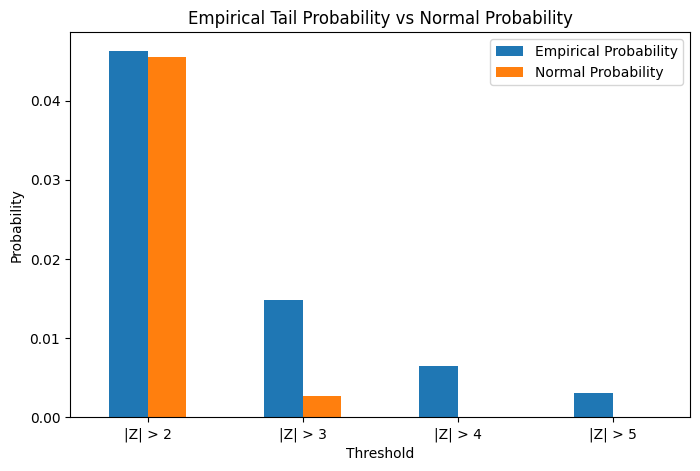

In [32]:
# 비교 결과 시각화
tail_prob_table.set_index("Threshold")[["Empirical Probability", "Normal Probability"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Empirical Tail Probability vs Normal Probability")
plt.ylabel("Probability")
plt.xlabel("Threshold")
plt.xticks(rotation=0)
plt.show()

시각화 결과에서도 실제 극단수익률의 발생 빈도와 정규분포의 이론적 확률 사이의 차이를 확인할 수 있다.  
특히 기준값이 커질수록, 즉 더 극단적인 수익률을 볼수록 정규분포가 예측하는 확률은 급격히 작아진다.

반면 실제 주식수익률 자료에서는 이러한 극단값이 완전히 사라지지 않고 반복적으로 관찰된다.  
이 차이가 바로 금융수익률에서 fat tail이 중요한 이유이다.

## 5. VaR and Expected Shortfall under Fat Tails

앞 절에서는 표준화된 수익률을 이용하여 극단수익률의 실제 발생 빈도를 확인하였다.  
이번 절에서는 같은 문제를 위험관리 지표의 관점에서 살펴본다.

꼬리확률의 차이는 단순히 분포의 모양이 다르다는 데서 끝나지 않는다.  
실제로 손실위험을 측정하는 방식에도 직접적인 영향을 줄 수 있다. 특히 정규분포를 가정하여 계산한 VaR가 실제 자료에서 관찰되는 하방위험을 충분히 반영하는지는 중요한 문제이다.

먼저 수익률 분포의 꼬리 특성을 요약하기 위해 초과첨도를 계산한다.  
정규분포의 첨도는 3이므로, 초과첨도는 다음과 같이 정의된다.

$$
\text{Excess Kurtosis} = \text{Kurtosis} - 3
$$

초과첨도가 0보다 크다면, 해당 수익률 분포는 정규분포보다 극단값이 더 자주 나타나는 경향을 가진다고 해석할 수 있다.

다음으로 실제 자료에서 계산한 1% VaR와 정규분포를 가정한 1% VaR를 비교한다.  
1% VaR는 수익률 분포의 하위 1% 지점에 해당하며, 손실위험의 경계값으로 해석할 수 있다.

또한 Expected Shortfall도 함께 계산한다.

$$
ES_{\alpha} = E[r_t \mid r_t \leq VaR_{\alpha}]
$$

VaR가 손실의 경계선을 보여준다면, Expected Shortfall은 그 경계선을 넘어선 구간에서 평균적으로 어느 정도의 손실이 발생했는지를 보여준다.

In [33]:
from scipy.stats import norm

# 초과첨도 계산
# pandas의 kurtosis()는 기본적으로 초과첨도를 반환한다.
excess_kurtosis = log_returns.kurtosis()

# 실제 자료에서 계산한 1% VaR
empirical_var_1 = log_returns.quantile(0.01)

# 정규분포를 가정한 1% VaR
normal_var_1 = log_returns.mean() + log_returns.std() * norm.ppf(0.01)

# 실제 자료에서 계산한 1% Expected Shortfall
expected_shortfall_1 = log_returns.apply(
    lambda x: x[x <= x.quantile(0.01)].mean()
)

# 결과 정리
risk_table = pd.DataFrame({
    "Excess Kurtosis": excess_kurtosis,
    "Empirical 1% VaR": empirical_var_1,
    "Normal 1% VaR": normal_var_1,
    "1% Expected Shortfall": expected_shortfall_1
})

# 정규분포 VaR와 경험적 VaR의 차이
risk_table["VaR Difference"] = (
    risk_table["Empirical 1% VaR"] - risk_table["Normal 1% VaR"]
)

# VaR 차이가 큰 순서로 정렬
risk_table = risk_table.sort_values("VaR Difference")

risk_table

,Excess Kurtosis,Empirical 1% VaR,Normal 1% VaR,1% Expected Shortfall,VaR Difference
Ticker,,,,,
TSLA,4.363540,-0.094773,-0.083157,-0.135496,-0.011615
AMZN,5.805887,-0.056975,-0.047098,-0.074422,-0.009877
UNH,27.007833,-0.052006,-0.042156,-0.084523,-0.009850
V,9.660667,-0.044512,-0.034897,-0.059632,-0.009615
MA,9.297367,-0.047469,-0.037869,-0.064289,-0.009600
NVDA,6.935918,-0.078030,-0.068726,-0.105826,-0.009304
ABBV,13.249239,-0.047898,-0.038627,-0.076082,-0.009271
BAC,9.768065,-0.053739,-0.044550,-0.075895,-0.009189
GOOGL,5.855905,-0.049734,-0.041290,-0.065724,-0.008445


위 표는 각 종목별 초과첨도, 경험적 1% VaR, 정규분포 기반 1% VaR, 그리고 1% Expected Shortfall을 정리한 것이다.

`Empirical 1% VaR`가 `Normal 1% VaR`보다 더 작은 값으로 나타난다면, 실제 자료에서 관찰된 하위 1% 손실이 정규분포가 예측한 손실보다 더 크다는 의미이다.  
이 경우 정규분포 기반 VaR는 실제 하방위험을 과소평가하고 있다고 볼 수 있다.

`1% Expected Shortfall`은 VaR보다 더 극단적인 손실 구간의 평균을 보여준다.  
따라서 VaR만으로는 꼬리의 깊이를 충분히 설명하기 어렵고, Expected Shortfall을 함께 보면 극단손실의 크기를 더 직접적으로 확인할 수 있다.

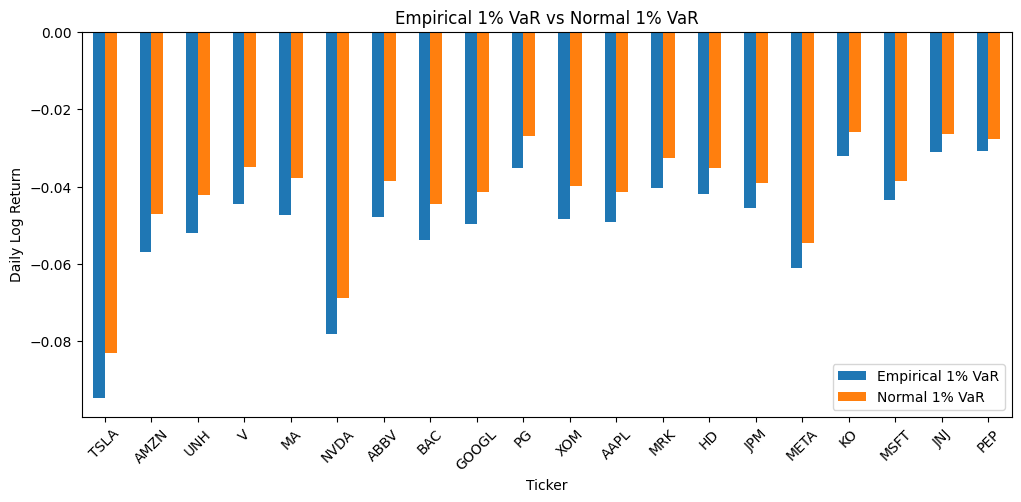

In [34]:
# 경험적 VaR와 정규분포 VaR 비교
var_compare = risk_table[["Empirical 1% VaR", "Normal 1% VaR"]]

var_compare.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Empirical 1% VaR vs Normal 1% VaR")
plt.ylabel("Daily Log Return")
plt.xlabel("Ticker")
plt.xticks(rotation=45)
plt.show()

위 그래프는 실제 자료에서 계산한 1% VaR와 정규분포를 가정하여 계산한 1% VaR를 비교한 것이다.

여러 종목에서 경험적 VaR가 정규분포 기반 VaR보다 더 낮게 나타난다면, 이는 실제 하방 꼬리가 정규분포가 가정하는 것보다 더 두껍다는 점을 보여준다.  
즉, 평균과 표준편차만으로 구성된 정규분포 기반 위험 측정은 극단적인 손실 가능성을 충분히 반영하지 못할 수 있다.

## In Closing

본 분석은 정규성 검정을 다시 수행하는 데 목적이 있지 않다.  
이미 실제 주식수익률이 정규분포와 잘 맞지 않는다는 점을 확인한 상태에서, 이번 분석은 그 차이가 특히 꼬리 부분에서 어떤 의미를 가지는지 살펴보는 데 초점을 두었다.

분석 결과, 실제 주식수익률에서는 정규분포가 예측하는 것보다 극단수익률이 더 자주 발생할 수 있음을 확인할 수 있었다.  
또한 이러한 차이는 단순한 빈도 비교에 그치지 않고, VaR와 Expected Shortfall 같은 위험관리 지표에서도 나타난다.

특히 정규분포 기반 VaR가 실제 경험적 VaR보다 덜 보수적으로 계산되는 경우, 정규분포 가정은 하방위험을 과소평가할 수 있다.  
이는 금융수익률 분석에서 평균과 분산만으로 위험을 설명하는 접근이 충분하지 않을 수 있음을 보여준다.

결국 fat tail은 단순한 통계적 예외가 아니라, 금융 데이터 분석에서 별도로 고려해야 할 중요한 특징이다.  
평균적인 시장 움직임을 설명하는 것만으로는 충분하지 않으며, 드물지만 큰 손실이 발생하는 꼬리 영역을 함께 살펴볼 필요가 있다. 2026.05.24